# Statistics for International Commerce
## Week 12 In-Class Practice Lab: Correlation and Simple Linear Regression

This notebook is designed for Google Colab.

Topics:
- scatterplots
- correlation
- simple linear regression
- interpretation of slope
- prediction
- business decisions


## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (8, 4.5)

np.random.seed(42)


# Part 1. Advertising and Sales

An international e-commerce company wants to study whether advertising spending is related to sales revenue.


In [2]:
advertising = np.array([20, 25, 28, 30, 35, 38, 40, 42, 45, 50,
                        52, 55, 58, 60, 62, 65, 68, 70, 75, 80])

sales = np.array([75, 82, 88, 92, 100, 110, 115, 120, 126, 138,
                  140, 148, 155, 160, 165, 170, 178, 182, 190, 200])

df = pd.DataFrame({
    "advertising_usd_thousands": advertising,
    "sales_usd_thousands": sales
})

df.head()


,advertising_usd_thousands,sales_usd_thousands
0,20,75
1,25,82
2,28,88
3,30,92
4,35,100


## Task 1A. Descriptive statistics

Compute:
- mean
- standard deviation
- minimum
- maximum


In [3]:
df.describe()


,advertising_usd_thousands,sales_usd_thousands
count,20.000000,20.00000
mean,49.900000,136.70000
std,17.438312,38.13149
min,20.000000,75.00000
25%,37.250000,107.50000
50%,51.000000,139.00000
75%,62.750000,166.25000
max,80.000000,200.00000


## Task 1B. Create a scatterplot

Question:
Does the relationship appear positive, negative, or weak?


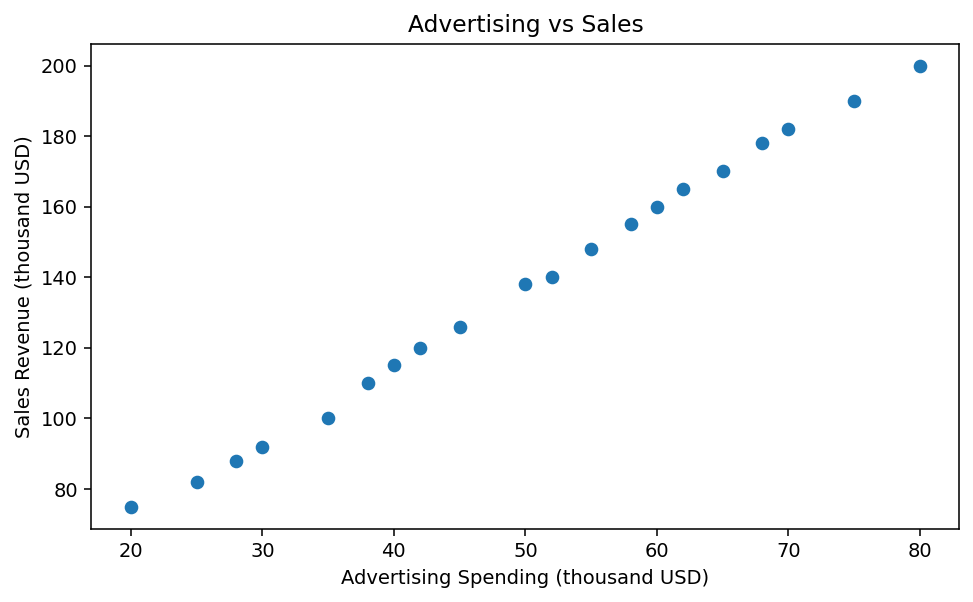

In [4]:
plt.scatter(df["advertising_usd_thousands"],
            df["sales_usd_thousands"])

plt.xlabel("Advertising Spending (thousand USD)")
plt.ylabel("Sales Revenue (thousand USD)")
plt.title("Advertising vs Sales")

plt.show()


## Task 1C. Correlation

Compute the correlation coefficient.


In [5]:
corr = df["advertising_usd_thousands"].corr(
    df["sales_usd_thousands"]
)

corr


np.float64(0.9990004932239122)

## Task 1D. Interpretation

Write 2–3 sentences:

- Is the relationship positive or negative?
- Is the relationship weak or strong?
- What does this mean for the company?


# Part 2. Simple Linear Regression

We now estimate a regression model.

Goal:
Predict sales using advertising spending.


In [6]:
X = sm.add_constant(df["advertising_usd_thousands"])

model = sm.OLS(
    df["sales_usd_thousands"],
    X
).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     sales_usd_thousands   R-squared:                       0.998
Model:                             OLS   Adj. R-squared:                  0.998
Method:                  Least Squares   F-statistic:                     8991.
Date:                 Fri, 15 May 2026   Prob (F-statistic):           9.42e-26
Time:                         14:33:59   Log-Likelihood:                -38.531
No. Observations:                   20   AIC:                             81.06
Df Residuals:                       18   BIC:                             83.05
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        27.6952      1.214     22.805      0.000      25.144      30.247
advertising_usd_thousands     2.1845      0.023     94.821      0.000       2.136       2.233
==============================================================================
Omnibus:                        1.956   Durbin-Watson:                   1.110
Prob(Omnibus):                  0.376   Jarque-Bera (JB):                0.619
Skew:                          -0.320   Prob(JB):                        0.734
Kurtosis:                       3.577   Cond. No.                         164.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Task 2A. Important output

Answer:

1. What is the intercept?
2. What is the slope coefficient?
3. What is the R-squared?


## Task 2B. Interpretation of the slope

Write 2–3 sentences:

What does the slope coefficient mean in business terms?


## Task 2C. Regression line


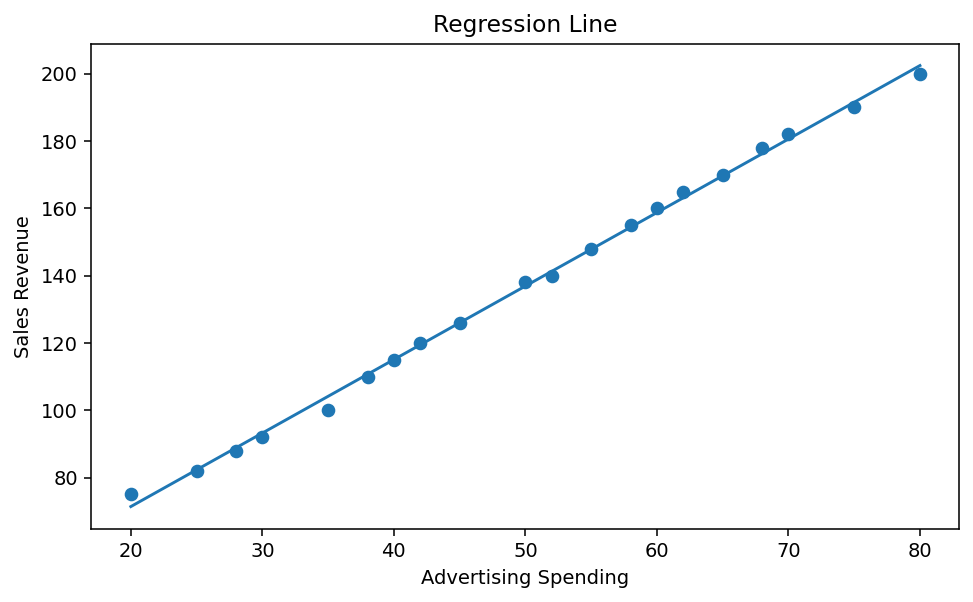

In [7]:
predicted = model.predict(X)

plt.scatter(df["advertising_usd_thousands"],
            df["sales_usd_thousands"])

plt.plot(df["advertising_usd_thousands"],
         predicted)

plt.xlabel("Advertising Spending")
plt.ylabel("Sales Revenue")
plt.title("Regression Line")

plt.show()


# Part 3. Prediction

Suppose the company plans to spend:

60 thousand USD on advertising.

Use the regression model to predict expected sales.


In [8]:
new_X = pd.DataFrame({
    "const": [1],
    "advertising_usd_thousands": [60]
})

prediction = model.predict(new_X)

prediction


0    158.763093
dtype: float64

## Task 3A. Interpretation

Write 2–3 sentences:

- What are the predicted sales?
- Should the company increase advertising?
- What limitation should managers keep in mind?


# Part 4. Delivery Time and Customer Rating

A logistics company wants to know whether longer delivery times reduce customer ratings.


In [9]:
delivery_days = np.array([2,3,3,4,4,5,5,6,6,7,7,8,8,9,10])

ratings = np.array([4.9,4.8,4.8,4.7,4.6,4.5,4.4,
                    4.3,4.2,4.1,4.0,3.9,3.8,3.7,3.5])

df2 = pd.DataFrame({
    "delivery_days": delivery_days,
    "customer_rating": ratings
})

df2.head()


,delivery_days,customer_rating
0,2,4.9
1,3,4.8
2,3,4.8
3,4,4.7
4,4,4.6


## Task 4A. Scatterplot


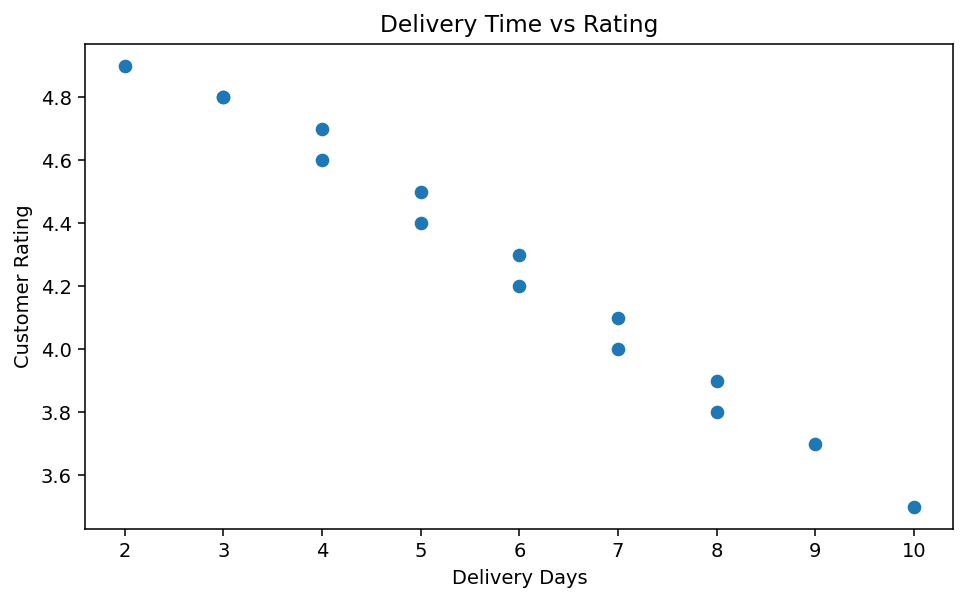

In [10]:
plt.scatter(df2["delivery_days"],
            df2["customer_rating"])

plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")
plt.title("Delivery Time vs Rating")

plt.show()


## Task 4B. Correlation


In [11]:
corr2 = df2["delivery_days"].corr(
    df2["customer_rating"]
)

corr2


np.float64(-0.9931318681318682)

## Task 4C. Interpretation

Write 2–3 sentences:

- Is the relationship positive or negative?
- What does this imply for logistics management?


# Part 5. Regression for Customer Ratings


In [12]:
X2 = sm.add_constant(df2["delivery_days"])

model2 = sm.OLS(
    df2["customer_rating"],
    X2
).fit()

model2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        customer_rating   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     936.7
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.68e-13
Time:                        14:34:00   Log-Likelihood:                 23.749
No. Observations:                  15   AIC:                            -43.50
Df Residuals:                      13   BIC:                            -42.08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.3497      0.038    142.391      0.000       5.269       5.431
delivery_days    -0.1844      0.006    -30.605      0.000      -0.197      -0.171
==============================================================================
Omnibus:                        0.471   Durbin-Watson:                   2.706
Prob(Omnibus):                  0.790   Jarque-Bera (JB):                0.530
Skew:                           0.050   Prob(JB):                        0.767
Kurtosis:                       2.085   Cond. No.                         17.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Task 5A. Interpretation

Answer:

1. What is the slope coefficient?
2. What does it mean in business terms?
3. Does longer delivery time appear harmful for customer satisfaction?


# Part 6. Residuals

Residuals are prediction errors.

Residual = Actual value − Predicted value


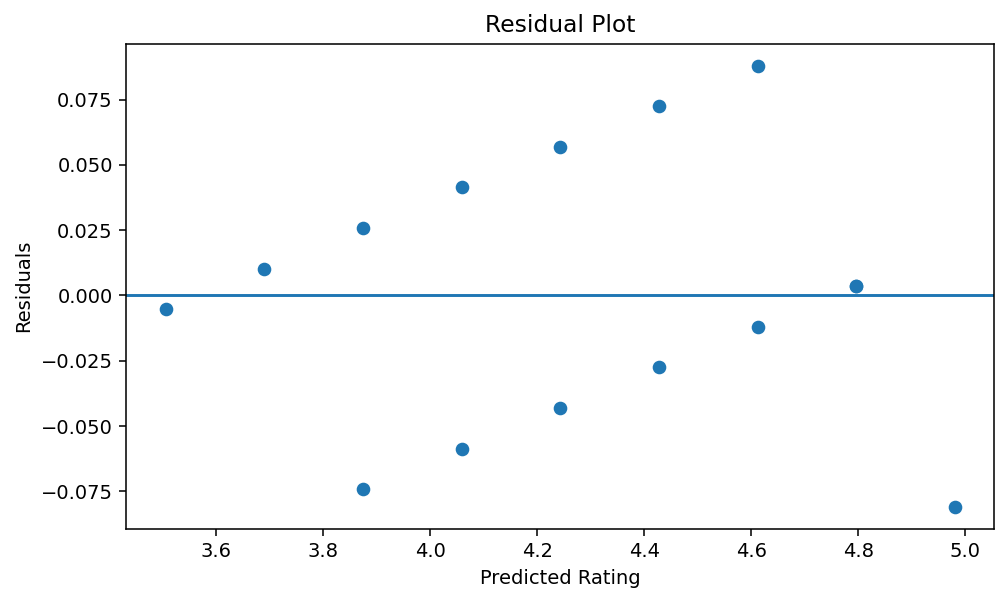

: 

In [ ]:
predicted2 = model2.predict(X2)

residuals = df2["customer_rating"] - predicted2

plt.scatter(predicted2, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


## Task 6A. Interpretation

Question:

Do the residuals appear random or patterned?

Why is this important?


# Part 7. Reflection Questions

Answer briefly:

1. What is the difference between correlation and regression?
2. Why does correlation not imply causation?
3. What does R-squared measure?
4. Give one international business application of regression analysis.


# End of Lab

Before submitting:
- run all cells
- answer all interpretation questions
- save the notebook to Google Drive
